In [241]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [242]:
df = pd.read_csv('source/FReDA4.csv')
df["Group4"] = None

In [243]:
# Satisfied
df.loc[df['Group3'] == 'Couple Satisfaction', 'Group4'] = 'Couple Satisfaction'

# Deprived groups
df.loc[df['Group1'] == 'SubGroup-DeprivedBoth', 'Group4'] = 'Deprived_Both'
df.loc[df['Group1'] == 'SubGroup-DeprivedMe', 'Group4'] = 'Deprived_Me'
df.loc[df['Group1'] == 'SubGroup-DeprivedPartner', 'Group4'] = 'Deprived_Partner'
#
# Oversaturated groups
df.loc[df['Group1'] == 'SubGroup-OversaturatedBoth', 'Group4'] = 'Oversaturated_Both'
df.loc[df['Group1'] == 'SubGroup-OversaturatedMe', 'Group4'] = 'Oversaturated_Me'
df.loc[df['Group1'] == 'SubGroup-OversaturatedPartner', 'Group4'] = 'Oversaturated_Partner'

df.loc[df['Group3'] == 'Couple Mixed', 'Group4'] = 'Couple Mixed'

In [244]:
def collapse_kde_into_bins(kde_df, bins=[0, 1, 2, 3, 4, 5, 6]):
    df = kde_df.copy()
    N = df["N_total"].iloc[0]

    dx = df["x"].diff().median()

    df["bin"] = pd.cut(df["x"], bins=bins, labels=range(len(bins) - 1), right=False)

    out = (
        df.groupby("bin")
        .apply(lambda g: pd.Series({
            "density_sum": (g["density"] * dx).sum(),
        }))
        .reset_index()
    )
    return out

In [245]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask1.get(cid, False) else 0
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask1.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask2.get(cid, False) else 0
)

df['Match_Desire_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask2.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask2.get(cid, False) else 0
)

In [246]:
df2 = df[df["Match_Frequency"] == "Aligned"].copy()
df3 = df[df["Match_Desire"] == "Aligned"].copy()

<Axes: xlabel='Relationship Length (years)', ylabel='Density'>

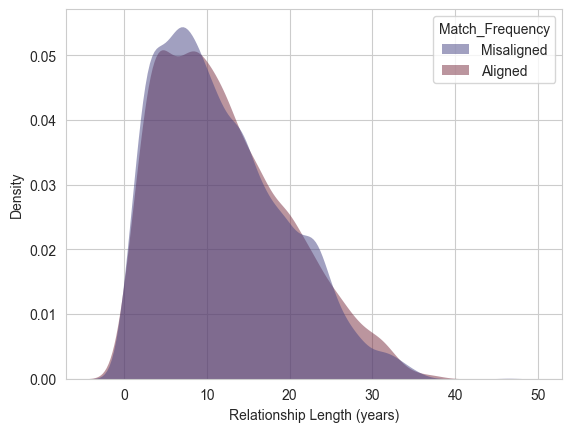

In [247]:
sns.kdeplot(
   data=df, x="Relationship Length (years)", hue="Match_Frequency",
   fill=True, common_norm=False, palette="icefire",
   alpha=.5, linewidth=0,
)

<Axes: xlabel='Relationship Satisfaction', ylabel='Density'>

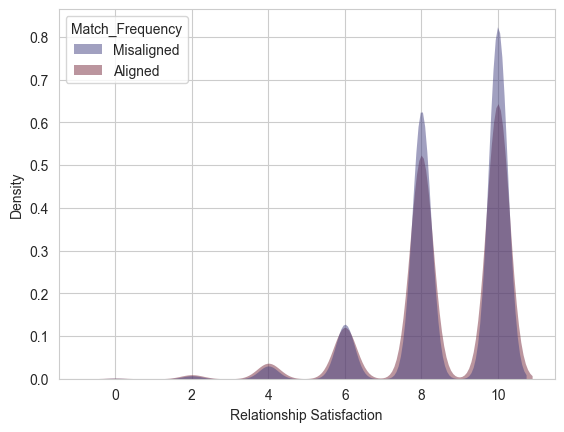

In [248]:
sns.kdeplot(
   data=df, x="Relationship Satisfaction", hue="Match_Frequency",
   fill=True, common_norm=False, palette="icefire",
   alpha=.5, linewidth=0,
)

<Axes: xlabel='Frequency_F', ylabel='Density'>

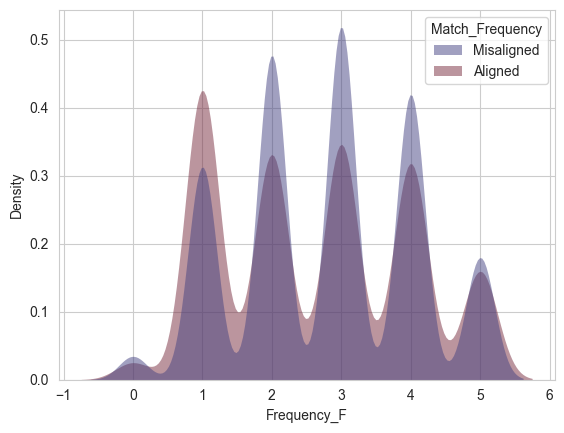

In [249]:
sns.kdeplot(
   data=df, x="Frequency_F", hue="Match_Frequency",
   fill=True, common_norm=False, palette="icefire",
   alpha=.5, linewidth=0,
)

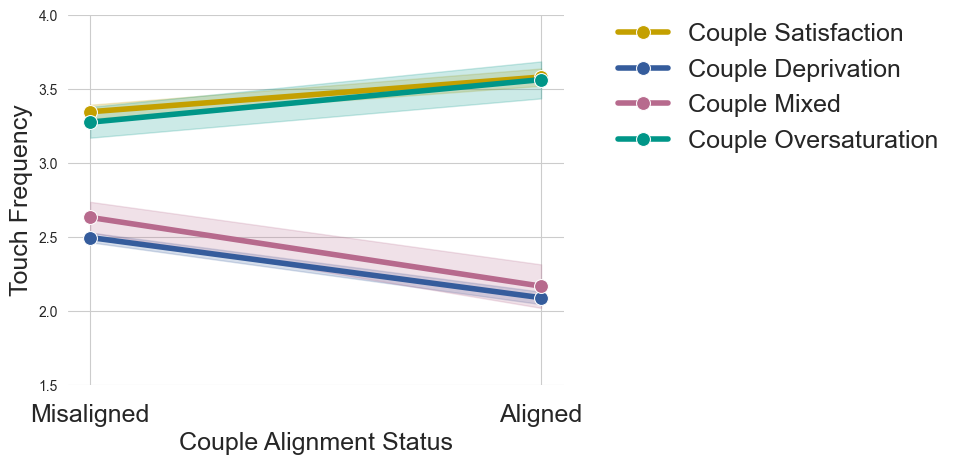

In [250]:
new_palette = [
    "#C4A000",
    "#355C9C",
    "#B76A8D",
    "#009688",
]


ax = sns.lineplot(
    data=df,
    y="Frequency_F",
    x="Match_Frequency",
    hue="Group3",
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Touch Frequency", fontsize=18)
plt.xlabel("Couple Alignment Status", fontsize=18)

plt.ylim(1.5, 4)

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.8, 1.04),
    fontsize=18,
    frameon=False,
)

sns.despine(top=True, right=True, left=True, bottom=True)
# t1 = plt.title("Frequency couples", fontsize=24, y=1.05, x=0.01, ha='left')

ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
plt.savefig('output/img/alignment/frequency.png', dpi=600, transparent=False, bbox_inches='tight')

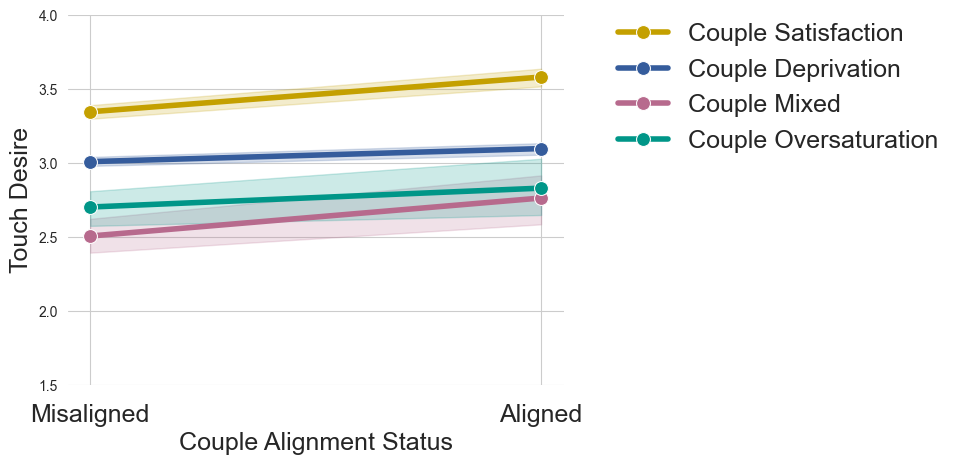

In [256]:
new_palette = [
    "#C4A000",
    "#355C9C",
    "#B76A8D",
    "#009688",
]

ax = sns.lineplot(
    data=df,
    y="Desire_F",
    x="Match_Desire",
    hue="Group3",
    style='Group3',
    palette=new_palette,
    markers=["o", "o", "o", "o"],
    markersize=10,
    dashes=False,
    linewidth=4,
)

plt.ylabel("Touch Desire", fontsize=18)
plt.xlabel("Couple Alignment Status", fontsize=18)

plt.ylim(1.5, 4)

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.8, 1.04),
    fontsize=18,
    frameon=False,
)

sns.despine(top=True, right=True, left=True, bottom=True)
# t1 = plt.title("Touch Desire", fontsize=24, y=1.05, x=0.01, ha='left')

ax.tick_params(axis='x', which='major', pad=10, labelsize=18)
plt.savefig('output/img/alignment/desire.png', dpi=600, transparent=False, bbox_inches='tight')

<Axes: xlabel='Match_Frequency', ylabel='Relationship Length (years)'>

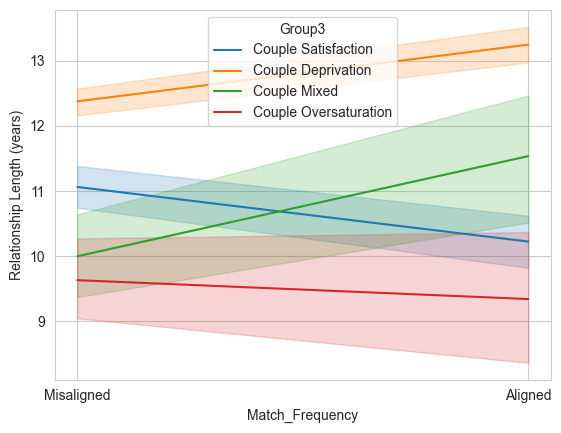

In [252]:
sns.lineplot(
    data=df,
    x="Match_Frequency",
    y="Relationship Length (years)",
    hue="Group3",
    style='Group3',
    # markers=["o", "o", "o", "o"],
    dashes=False,
)

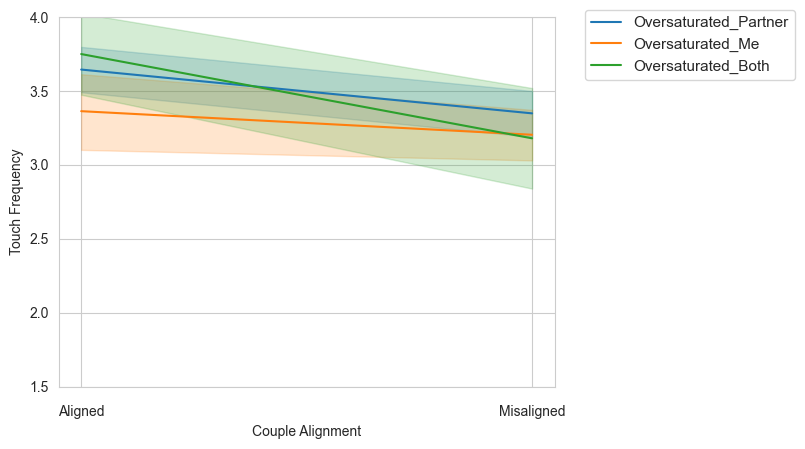

In [253]:
# new_palette = [
#     "#C4A000",
#     "#355C9C",
#     "#B76A8D",
#     "#009688",
# ]
# target_values = ['Deprived_Both', 'Deprived_Me', 'Deprived_Partner']
target_values = ['Oversaturated_Both', 'Oversaturated_Me', 'Oversaturated_Partner']
df_filtered = df[df['Group4'].isin(target_values)]

ax = sns.lineplot(
    data=df_filtered,
    y="Frequency_F",
    x="Match_Frequency",
    hue="Group4",
    style='Group4',
    # palette=new_palette,
    # markers=["o", "o", "o", "o"],
    dashes=False,
)

plt.ylabel("Touch Frequency")
plt.xlabel("Couple Alignment")

plt.ylim(1.5, 4)
# plt.xticks([0, 1], labels=["Align", "Disalign"])

x_legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.5, 1.04),
    fontsize=11
)

ax.tick_params(axis='x', which='major', pad=10)

<Axes: xlabel='Relationship Satisfaction', ylabel='Match_Frequency_n'>

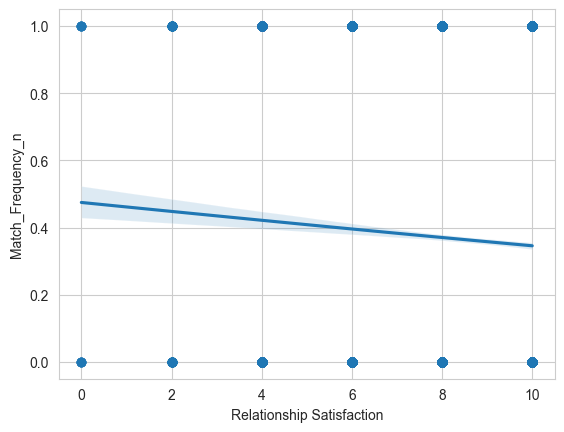

In [254]:
sns.regplot(
    data=df,
    # x="Relationship Length (years)",
    x="Relationship Satisfaction",
    y="Match_Frequency_n",
    logistic=True
)

In [255]:
df_long = pd.melt(
    df,
    id_vars=['Frequency_F'],
    value_vars=['Relationship Satisfaction', 'Relationship Length (years)'],
    var_name='var_alignment',
    value_name='Value'
)

print("Reshaped DataFrame:")
print(df_long)

Reshaped DataFrame:
       Frequency_F                var_alignment      Value
0                3    Relationship Satisfaction  10.000000
1                1    Relationship Satisfaction   6.000000
2                1    Relationship Satisfaction  10.000000
3                2    Relationship Satisfaction   6.000000
4                2    Relationship Satisfaction   8.000000
...            ...                          ...        ...
27195            2  Relationship Length (years)  10.416670
27196            1  Relationship Length (years)  20.416670
27197            3  Relationship Length (years)  14.583330
27198            4  Relationship Length (years)  11.250000
27199            1  Relationship Length (years)   8.916667

[27200 rows x 3 columns]
